# Analisi del dataset `training.csv`
Verifichiamo che il dataset `training.csv` non contenga osservazioni palesemente errate ed effettuiamo un'analisi esplorativa del dataset rappresentando i dati in forma grafica sfruttando elementi come i boxplot, i pairplot e la matrice di correlazione.


## 1 - Verifica del dataset `training.csv`
Il dataset `training.csv` contiene un elevato numero di righe: ben 50mila. Ovviamente non possiamo analizzare manualmente ciascuna riga per capire se ci sono osservazioni palesemente errate, si automatizzano quindi grazie ad un codice python 4 tipi di controllo:

- **Valori mancanti**: Ci sono righe con celle vuote/NaN?
- **Tipi e range plausibili di valori**: Label può essere solo 0/1. TIMESTAMP/USERDID/TARGETID non devono essere negativi.
- **Righe duplicate**: La stessa osservazione è ripetuta in più righe.
- **Contraddizioni sulla chiave ACTIONID**: Verifichiamo che lo stesso ACTIONID non compaia in più righe con valori diversi delle celle. ACTIONID infatti identifica un'azione in maniera univoca.

_**Nota:** NaN = Not a Number, è il modo in cui pandas rappresenta una cella vuota/mancante in una colonna numerica. Capita quando, per qualche riga, un valore non è stato registrato (es. un sensore che non ha letto un dato, un errore di importazione, un campo lasciato vuoto nel file originale)._

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("../data/training.csv")

"""Valori mancanti"""
print("Numero di valori Nan per ciascuna colonna di training.csv:")
#df.isna() trasforma ciascuna cella del dataframe in un valore booleano (True se il valore è NaN, False altrimenti).
#.sum() somma i valori booleani per ciascuna colonna, restituendo il numero di valori NaN presenti in ciascuna colonna del dataframe.
print(df.isna().sum())
print("Numero totale di valori Nan in training.csv:", df.isna().sum().sum())

"""Tipi e range plausibili di valori"""
#assert condizione, messaggio è un'istruzione che verifica se la condizione è vera. Se è falsa l'esecuzione del programma si interrompe e viene stampato il messaggio di errore.
#df["LABEL"].unique() restituisce tutti i valori unici presenti nella colonna "LABEL" del dataframe df.
#set(df["LABEL"].unique()) trasfroma quei valori unici in un insieme (set) per facilitare il confronto.
#<= {0, 1} verifica se l'insieme dei valori unici della colonna "LABEL" è un sottoinsieme dell'insieme {0, 1}, cioè se tutti i valori presenti in "LABEL" sono solo 0 o 1.
assert set(df["LABEL"].unique()) <= {0, 1}, "\nLABEL contiene valori diversi da 0/1"
#df["TIMESTAMP"] >= 0 confronta ciascun valore della colonna "TIMESTAMP" con 0, restituendo una colonna di valori booleani (True se il valore è maggiore o uguale a 0, False altrimenti).
#.all() restituisce True se tutti i valori della colonna sono True, cioè se tutti i valori di "TIMESTAMP" sono maggiori o uguali a 0.
assert (df["TIMESTAMP"] >= 0).all(), "\nTimestamp negativo trovato"
#Ragionamento analogo a sopra per l'assert sottostante.
assert (df["USERID"] >= 0).all(), "\nUSERID negativo trovato"
assert (df["TARGETID"] >= 0).all(), "\nTARGETID negativo trovato"
#La riga sottostante viene eseguita solo se tutti gli assert precedenti sono stati superati.
print("\nControlli di range superati.")

"""Righe duplicate"""
#.duplicated() restituisce false se una riga non l'ha mai incontrata prima, true se l'ha già incontrata.
#con .sum() si contano le righe "di troppo" rispetto alla prima occorenza di ciascuna riga duplicata.
print("\nRighe duplicate:", df.duplicated().sum())
#eliminiamo le righe duplicate con .drop_duplicates(), che restituisce un nuovo dataframe senza le righe duplicate.
df_clean = df.drop_duplicates()

"""Contraddizioni sulla chiave ACTIONID"""
#duplicated(keep=False) marca True tutte le righe con lo stesso ACTIONID. stesso_id è quindi una colonna booleana con true per tutte le righe che hanno un ACTIONID duplicato e false per le altre.
stesso_id = df_clean["ACTIONID"].duplicated(keep=False)
#riga_identica è una colonna booleana che indica se una riga è identica a un'altra riga (True) o meno (False).
riga_identica = df_clean.duplicated(keep=False)
#troviamo quelle righe con stesso ACTIONID ma che non sono identiche tra loro. Queste righe rappresentano una contraddizione nei dati.
anomalie_id = df_clean[stesso_id & ~riga_identica].sort_values("ACTIONID")
#stampiamo il numero di osservazioni con ACTIONID duplicato ma dati contraddittori e una tabella.
print(f"\nOsservazioni con stessoACTIONID ma che presentano dati contraddittori: {len(anomalie_id)}")
anomalie_id
#rimuoviamo da df_clean le righe con ACTIONID uguale ma dati diversi.
df_clean = df_clean.drop(anomalie_id.index)

Numero di valori Nan per ciascuna colonna di training.csv:
ACTIONID     0
USERID       0
TARGETID     0
TIMESTAMP    0
FEATURE0     0
FEATURE1     0
FEATURE2     0
FEATURE3     0
LABEL        0
dtype: int64
Numero totale di valori Nan in training.csv: 0

Controlli di range superati.

Righe duplicate: 195

Osservazioni con stessoACTIONID ma che presentano dati contraddittori: 6


## 2 - Analisi esplorativa
Utilizziamo il comando `.describe()` sul dataframe df_clean per ottenere alcune statistiche descrittive di base sul dataset `training.csv`. 


In [8]:
FEATS = ["FEATURE0", "FEATURE1", "FEATURE2", "FEATURE3"]

df_clean[FEATS].describe()

,FEATURE0,FEATURE1,FEATURE2,FEATURE3
count,49799.000000,49799.000000,49799.000000,49799.000000
mean,0.002770,0.085252,-0.021543,0.000897
std,0.986119,1.130958,0.534993,0.708396
min,-0.319991,-0.435701,-0.394237,-0.067309
25%,-0.319991,-0.435701,-0.394237,-0.067309
50%,-0.319991,-0.435701,0.106784,-0.067309
75%,-0.319991,-0.435701,0.106784,-0.067309
max,25.293572,98.796794,54.718090,68.570723


LABEL
0    49309
1      490
Name: count, dtype: int64
LABEL
0    0.99016
1    0.00984
Name: proportion, dtype: float64


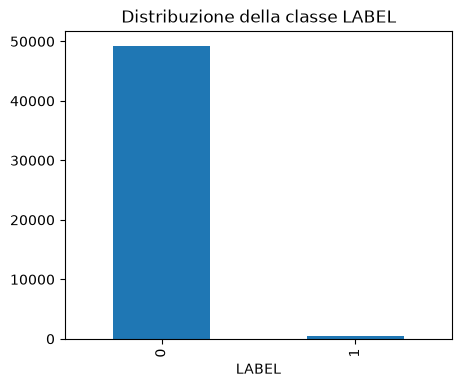

In [9]:
# Distribuzione della variabile target: conteggi e percentuali
print(df_clean["LABEL"].value_counts())
print(df_clean["LABEL"].value_counts(normalize=True))

# grafico a barre in stile pandas (come df.plot visto a lezione)
df_clean["LABEL"].value_counts().plot(kind="bar", figsize=(5, 4),
                                      title="Distribuzione della classe LABEL")
plt.show()

Il dataset è fortemente sbilanciato: la classe 0 (nessun abbandono) copre il ~99% delle osservazioni, la classe 1 (dropout) solo l'1% (493 su 49.799).

### Analisi delle feature per classe

Confrontiamo la distribuzione delle 4 feature nelle due classi tramite GroupBy: se le distribuzioni differiscono tra classe 0 e classe 1,
la feature contiene informazione utile a distinguere i dropout.
Il confronto grafico corrispondente (boxplot per classe) è nella sezione 3.1.

In [12]:
# describe() per classe, rimodellato per un confronto leggibile:
# - unstack(level=0) sposta le feature dalle righe alle colonne
# - swaplevel + sort_index raggruppa le colonne per feature (classe 0 e 1 affiancate)
# - reindex rimette le statistiche nell'ordine standard di describe()
tab = df_clean.groupby("LABEL")[FEATS].describe().T.unstack(level=0)
tab = tab.swaplevel(0, 1, axis=1).sort_index(axis=1)
tab = tab.reindex(["count", "mean", "std", "min", "25%", "50%", "75%", "max"])
tab

FEATURE0                  FEATURE1                  FEATURE2  \
LABEL             0           1             0           1             0   
count  49309.000000  490.000000  49309.000000  490.000000  49309.000000   
mean       0.004911   -0.212695      0.078096    0.805354     -0.020379   
std        0.989322    0.538046      1.127164    1.273130      0.536737   
min       -0.319991   -0.319991     -0.435701   -0.435701     -0.394237   
25%       -0.319991   -0.319991     -0.435701   -0.435701     -0.394237   
50%       -0.319991   -0.319991     -0.435701   -0.435701      0.106784   
75%       -0.319991   -0.319991     -0.435701    2.108722      0.106784   
max       25.293572    5.072338     98.796794    2.108722     54.718090   

                       FEATURE3              
LABEL           1             0           1  
count  490.000000  49309.000000  490.000000  
mean    -0.138614      0.001208   -0.030447  
std      0.290548      0.710952    0.368824  
min     -0.394237     -0.067309   -0.067309  
25%     -0.394237     -0.067309   -0.067309  
50%     -0.394237     -0.067309   -0.067309  
75%      0.106784     -0.067309   -0.067309  
max      0.607805     68.570723    7.559139

**Osservazioni sul confronto per classe:**

- **FEATURE1 è la più discriminante**: media ≈ 0.81 nella classe 1 (dropout)
  contro ≈ 0.08 nella classe 0 — un ordine di grandezza di differenza. La
  feature assume pochi valori distinti: quelli alti (≈ 2.11) compaiono nel
  ~49% delle azioni seguite da abbandono, contro il ~20% delle altre.
- **FEATURE0 e FEATURE2** mostrano differenze più contenute ma coerenti: nei
  dropout la media è più negativa (FEATURE0 ≈ −0.21 contro ≈ 0.00; FEATURE2
  ≈ −0.14 contro ≈ −0.02), segno che i valori alti di queste feature sono
  associati quasi esclusivamente alla classe 0. È coerente con il Task 2, dove
  la radice dell'albero manuale (FEATURE2 > 3.11 → classe 0) sfruttava proprio
  questa asimmetria.
- **FEATURE3 appare quasi indifferente al target**: mediane identiche e medie
  quasi uguali nelle due classi.
- Le distribuzioni sono quasi-discrete e molto concentrate: per FEATURE0,
  FEATURE1 e FEATURE3 l'80-93% dei valori coincide con il minimo (FEATURE2 è
  la più variegata, ~34%). Le mediane delle due classi coincidono quasi
  ovunque: **le differenze tra le classi non stanno nel centro della
  distribuzione ma nelle frequenze dei valori di coda** — un motivo in più
  per cui i boxplot per classe e il confronto delle medie sono più informativi
  della sola mediana.

## 3 - Rappresentazione in forma grafica
Analizziamo il dataset `training.csv` grazie alle seguenti tre forme di rappresentazione grafica:

- **Boxplot** (uno per ciascuna delle 4 feature): mostra mediana, quartili ed
   eventuali outlier, evidenziando come sono distribuiti i valori di ogni feature.
- **Matrice di correlazione** (tabella): riporta il coefficiente di correlazione
   tra ogni coppia di variabili (le 4 feature e LABEL), per capire quanto sono
   legate tra loro.
- **Heatmap della matrice di correlazione**: la stessa informazione della
   tabella precedente, rappresentata come mappa a colori per essere letta
   più rapidamente.

### 3.1 - Boxplot

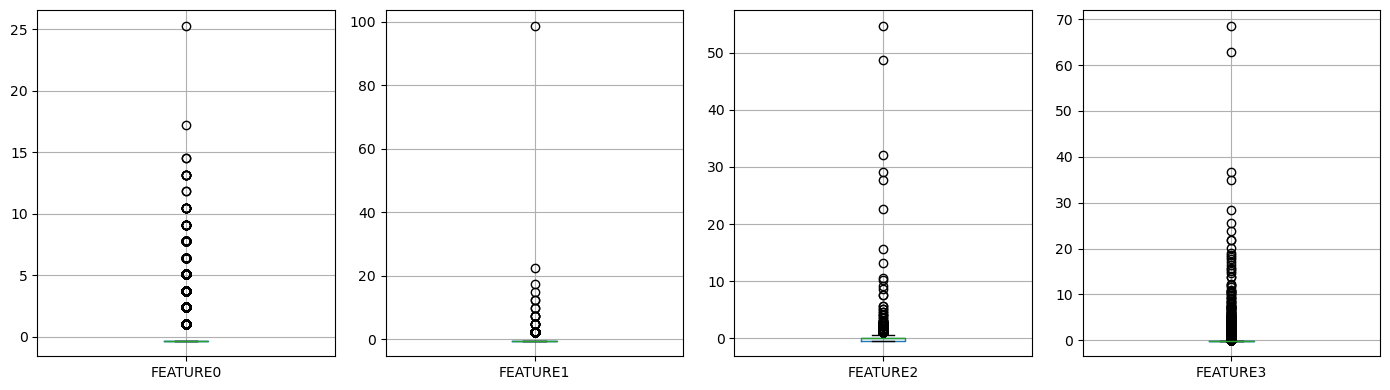

In [ ]:
fig, assi = plt.subplots(1, 4, figsize=(14, 4))
for ax, f in zip(assi, FEATS):
    df_clean.boxplot(column=f, ax=ax)
plt.tight_layout()
plt.show()

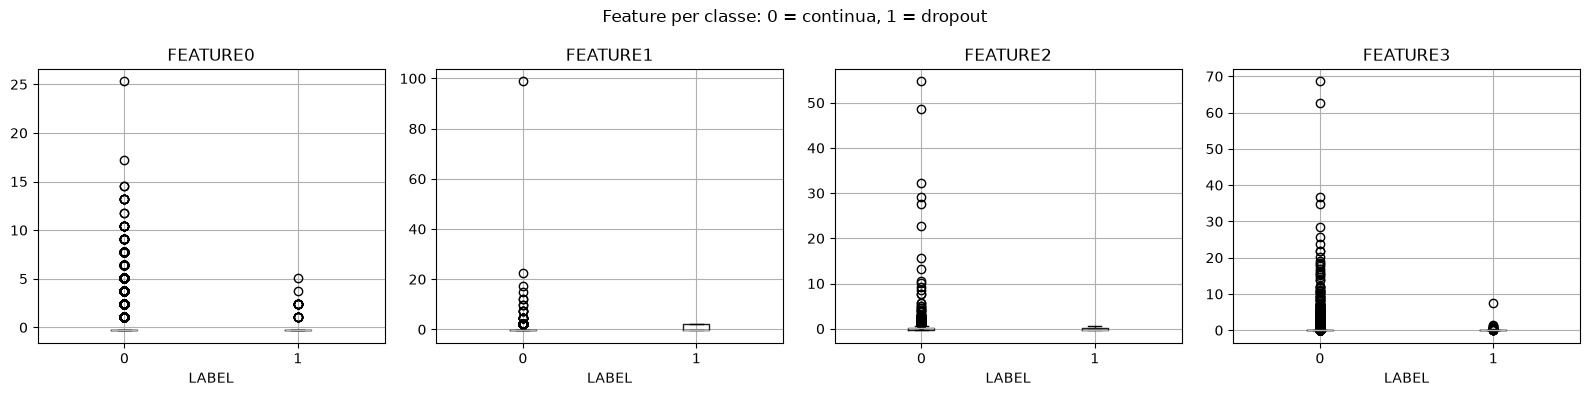

In [11]:
# boxplot di ogni feature affiancando le due classi (parametro by=):
# stessa scala per confrontare direttamente la distribuzione nei due gruppi
fig, assi = plt.subplots(1, 4, figsize=(16, 4))
for ax, f in zip(assi, FEATS):
    df_clean.boxplot(column=f, by="LABEL", ax=ax)
plt.suptitle("Feature per classe: 0 = continua, 1 = dropout")
plt.tight_layout()
plt.show()

**Lettura dei boxplot per classe:** il confronto conferma visivamente la tabella precedente. Da notare che il boxplot globale, a causa dello sbilanciamento 99/1, coincide di fatto con quello della sola classe 0: solo separando le classi la minoranza (493 dropout) diventa visibile. Le differenze di distribuzione — in particolare per FEATURE1 — indicano che le feature contengono informazione utile alla classificazione, pur con forte sovrapposizione tra le classi: nessuna feature separa nettamente i dropout da sola.

### 3.2 - Istogrammi delle feature

Le feature hanno code molto lunghe (es. FEATURE1 arriva a ~98 con la maggioranza
dei valori sotto 1): l'istogramma sui valori grezzi risulta illeggibile, con
quasi tutti i dati schiacciati nel primo bin.
In questi casi si rappresenta l'istogramma del logaritmo dei valori, che
comprime le code e rende visibile la forma della distribuzione. Poiché le
feature contengono valori negativi, prima del logaritmo trasliamo i valori
(x − min + 1) per renderli positivi.

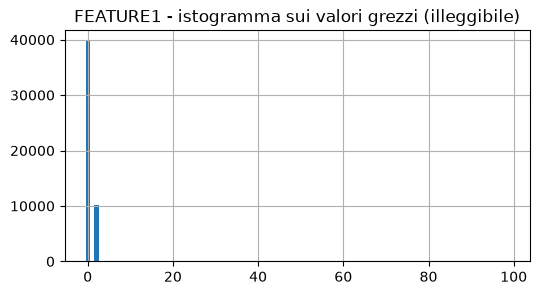

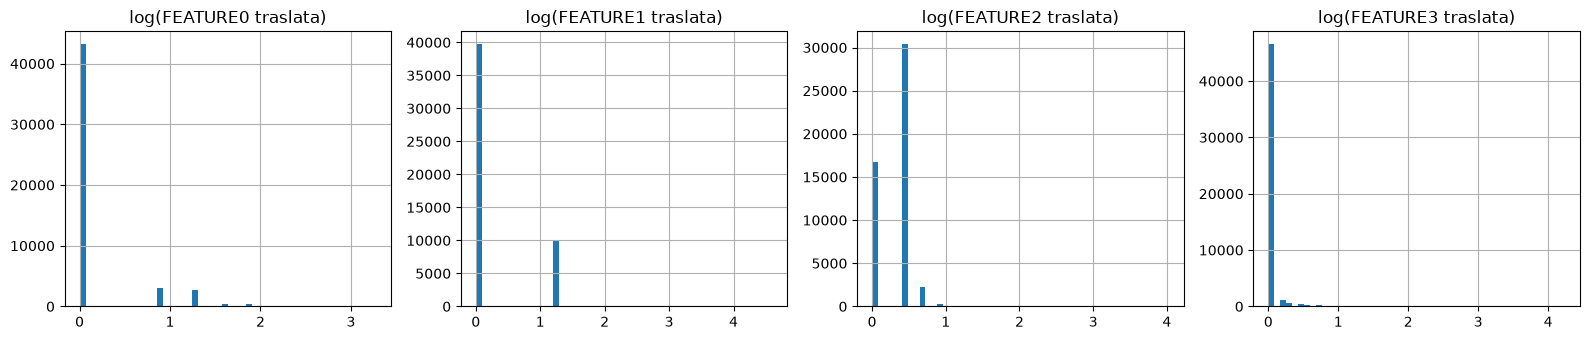

In [13]:
# Prima l'istogramma grezzo di una feature, per mostrare il problema:
# quasi tutti i valori nel primo bin, il resto invisibile
df_clean["FEATURE1"].hist(bins=100, figsize=(6, 3))
plt.title("FEATURE1 - istogramma sui valori grezzi (illeggibile)")
plt.show()

# Poi gli istogrammi del logaritmo per tutte e 4 le feature:
# la traslazione x - min + 1 rende i valori positivi (log definito solo per x > 0)
fig, assi = plt.subplots(1, 4, figsize=(16, 3.5))
for ax, f in zip(assi, FEATS):
    log_vals = np.log(df_clean[f] - df_clean[f].min() + 1)
    log_vals.hist(bins=50, ax=ax)
    ax.set_title(f"log({f} traslata)")
plt.tight_layout()
plt.show()

**Lettura degli istogrammi:** anche dopo la trasformazione logaritmica non
emergono distribuzioni continue "a campana", ma poche barre isolate: le feature
sono di fatto **quasi-discrete** (14, 8, 23 e 62 valori distinti rispettivamente),
cioè si comportano come variabili categoriche codificate numericamente. Il caso
estremo è FEATURE1, concentrata su due soli valori (il minimo ≈ −0.44, ~80% delle
righe, e ≈ 2.11, ~20%).

### 3.3 - Matrice di correlazione

In [24]:
# corr(numeric_only=True) calcola la correlazione tra tutte le coppie di colonne numeriche
correlazioni = df_clean[FEATS + ["LABEL"]].corr(numeric_only=True)
correlazioni

,FEATURE0,FEATURE1,FEATURE2,FEATURE3,LABEL
FEATURE0,1.000000,-0.150769,-0.228016,0.166399,-0.021781
FEATURE1,-0.150769,1.000000,-0.320897,-0.040051,0.063473
FEATURE2,-0.228016,-0.320897,1.000000,0.090169,-0.021814
FEATURE3,0.166399,-0.040051,0.090169,1.000000,-0.004411
LABEL,-0.021781,0.063473,-0.021814,-0.004411,1.000000


**Lettura della matrice di correlazione:** le correlazioni tra le feature sono
tutte deboli (|r| < 0.33): le quattro feature non sono ridondanti tra loro,
ciascuna porta informazione propria.

La correlazione tra le feature e LABEL appare bassissima (il massimo è
FEATURE1–LABEL = 0.063), il che sembrerebbe contraddire l'analisi per classe
della sezione 2, dove FEATURE1 mostrava una media 10 volte diversa tra le
classi. Non c'è contraddizione: **con classi sbilanciate 99/1 il coefficiente
di correlazione è dominato dalla classe maggioritaria** — la variabilità di
LABEL è minima (quasi tutti 0) e anche una feature fortemente associata al
dropout produce un r globale piccolo. È un ulteriore esempio del perché, su
questo dataset, le statistiche globali (correlazione, accuracy) vanno sempre
affiancate ad analisi condizionate per classe.

### 3.4 - Heatmap della matrice di correlazione

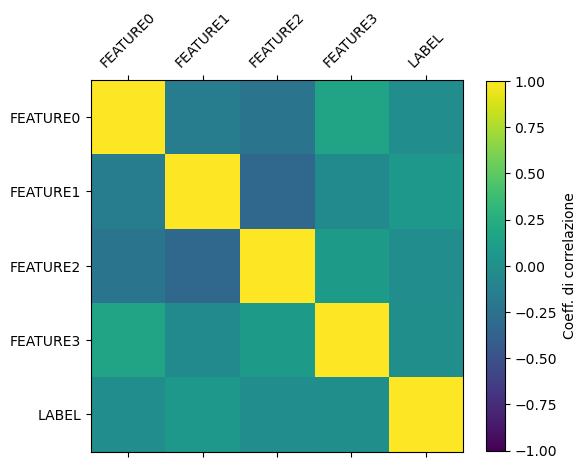

In [25]:
import numpy as np

nomi = list(correlazioni.columns)
fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(111)
cax = ax.matshow(correlazioni, vmin=-1, vmax=1)
fig.colorbar(cax, shrink=0.8, label="Coeff. di correlazione")
ticks = np.arange(len(nomi))
ax.set_xticks(ticks)
ax.set_yticks(ticks)
ax.set_xticklabels(nomi, rotation=45)
ax.set_yticklabels(nomi)
plt.show()

### 3.5 - Scatter matrix

La scatter matrix (equivalente pandas del pairplot) mostra un grafico di
dispersione per ogni coppia di feature, con gli istogrammi sulla diagonale.
Coloriamo i punti per classe (blu = continua, rosso = dropout) per valutare
visivamente se le classi occupano regioni diverse dello spazio delle feature.
Usiamo un sottocampione bilanciato (1000 righe per classe): con tutte le 49.799
righe il 99% di punti blu coprirebbe completamente i rari punti rossi.

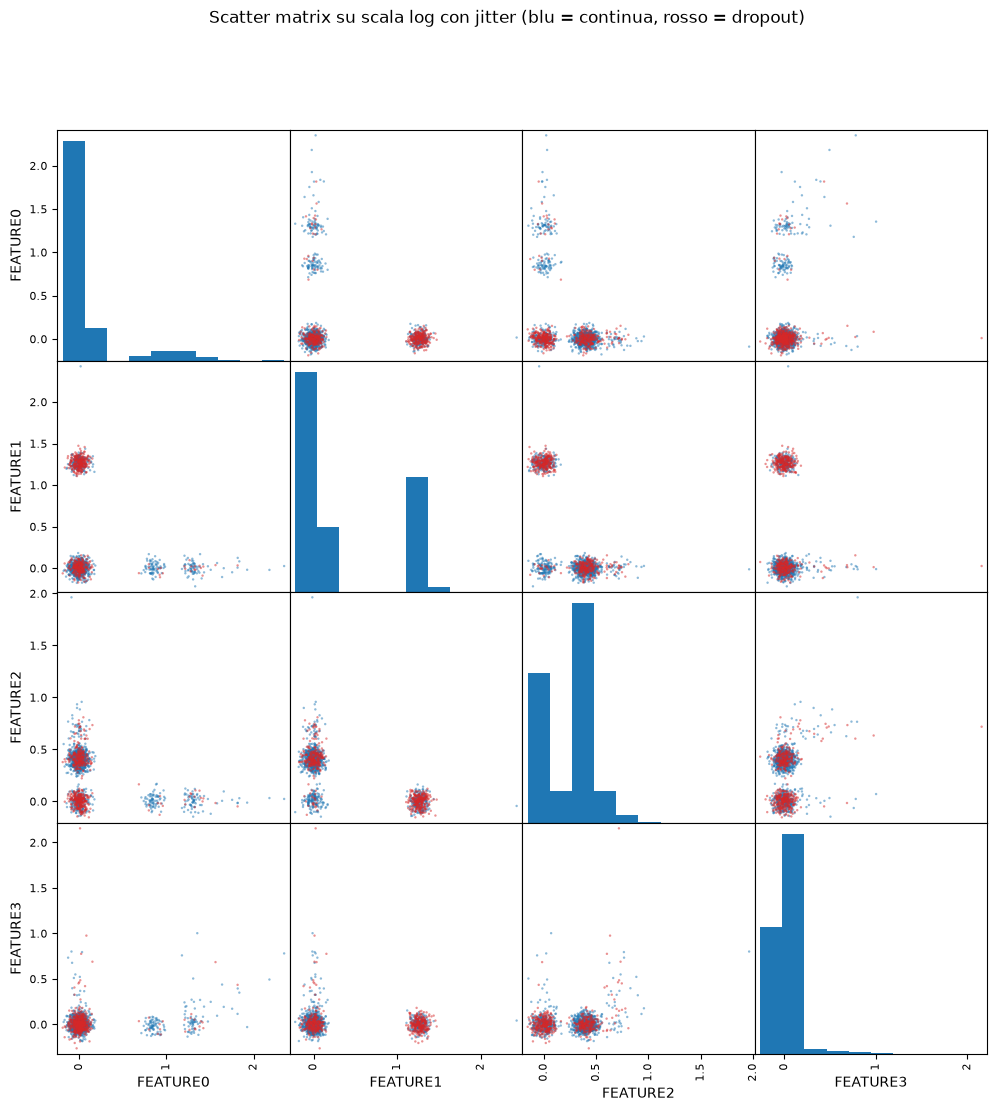

In [16]:
# ordine: prima la classe 0, POI i dropout, così i punti rossi
# vengono disegnati sopra i blu e restano visibili
continua = df_clean[df_clean["LABEL"] == 0].sample(n=1000, random_state=42)
dropout  = df_clean[df_clean["LABEL"] == 1]
campione = pd.concat([continua, dropout])

# trasformazione log (come per gli istogrammi): spalma i valori concentrati
log_feats = np.log(campione[FEATS] - df_clean[FEATS].min() + 1)

# jitter: piccolo rumore casuale per separare i punti impilati sulla stessa
# coordinata (le feature sono quasi-discrete). Solo per il grafico!
rng = np.random.default_rng(42)
jittered = log_feats + rng.normal(0, 0.06, size=log_feats.shape)

colori = campione["LABEL"].map({0: "tab:blue", 1: "tab:red"})
pd.plotting.scatter_matrix(jittered, figsize=(12, 12), c=colori, alpha=0.5, s=12)
plt.suptitle("Scatter matrix su scala log con jitter (blu = continua, rosso = dropout)")
plt.show()

## 4 - Conclusioni dell'analisi esplorativa

1. **Qualità dei dati**: nessun valore mancante e range tutti plausibili; trovati
   e rimossi 195 duplicati esatti e 6 osservazioni contraddittorie ereditati da
   un difetto del file di label originale. Il dataset pulito (`training_clean.csv`,
   49.799 righe) è l'input degli step successivi.
2. **Sbilanciamento estremo**: la classe dropout è ~1% delle osservazioni. Le
   valutazioni degli step 4-5 dovranno basarsi su precision/recall/F1 della
   classe minoritaria (l'accuracy sarebbe fuorviante) e gli split train/test
   dovranno essere stratificati.
3. **Feature quasi-discrete**: poche decine di valori distinti per feature,
   distribuzioni concentrate sul minimo con code lunghe. Gli "outlier" sono
   valori rari legittimi, non errori: nessuna rimozione.
4. **Potere discriminante**: FEATURE1 è la più associata al dropout (valori alti
   nel ~49% dei dropout contro ~20%); FEATURE0 e FEATURE2 contribuiscono
   (valori alti ⇒ quasi sempre classe 0); FEATURE3 appare poco informativa.
   Nessuna feature separa le classi da sola: i modelli dovranno combinarle.
5. **Feature non ridondanti**: correlazioni reciproche deboli; la correlazione
   quasi nulla con LABEL è un artefatto dello sbilanciamento, non assenza di
   segnale.

In [17]:
# Salviamo la versione pulita del dataset: sarà l'input degli step 4 e 5
# (49.799 righe: 50.000 - 195 duplicati esatti - 6 contraddizioni)
df_clean.to_csv("../data/training_clean.csv", index=False)
print("Salvato:", df_clean.shape)

Salvato: (49799, 9)
